# Playground

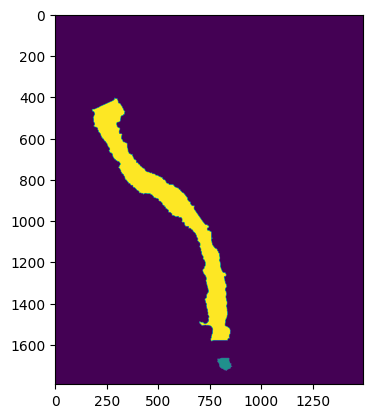

# Operator

This is the top level of management that connetcs `Registry` to generate data from the dataset *(selected slides in dataset.csv)*

- The `data_paths` are then saved into an internal cache **slide_data_paths** in `Manager` for accessing any **data modes**
- The `tile_extractions` are then saved with **keys** of `tile_class`  in `Manager` 
    - for **accessing extractions** from any **tile class** *(the dataset its referenced from)*

`Operator` is a higher level class that simplifies further for usage of manager resources

Setting up the environmnet:
1. `root_dir` is the location of the database
2. `models_save_dir` is the location of the foundational models used for extracting slide embeddings
3. Assign `Backbone` as the model storage for different foundational models
4. Assign `Operator` as the main interface

Note: 
- `Operator` is defined per `session` *(1 user may have 1+1: generating and interface)*
- `Backbone` is shared for all

## Setup

In [1]:
# for notebook
import sys
sys.path.append('..')

import apeiron as ap
from matplotlib import pyplot as plt
import numpy as np

root_dir = "/mnt/a/APEIRON_v1/DATABASE"
models_save_dir = "/mnt/a/APEIRON_v1/MODELS/foundational_models"

backbone = ap.Backbone(models_save_dir)
operator = ap.Operator(backbone=backbone, root_dir=root_dir, device='cuda')

2026-05-12 01:38:59.998205: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 01:39:00.111426: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 01:39:01.347736: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


backbone -- Device: GPU (NVIDIA GeForce RTX 4070 Ti SUPER)


You can **reset** the `operator` to different *project_path* via `setup`

In [2]:
# Here we just use back project_path as ../user1/task1
# project_path = "/mnt/a/APEIRON_v1/PROJECTS/user1/task3_breast_cam"
project_path = "/mnt/a/APEIRON_v1/PROJECTS/user1/task5_gleason_kag"
# project_path = "/mnt/a/APEIRON_v1/PROJECTS/user1/task2"

operator.setup(project_path)

example_name = operator.collector.slide_dataset['slide_name'][0]
example_id = operator.collector.slide_dataset['slide_id'][0]
print('name:', example_name, 'id:', example_id)

operator.collector.slide_dataset

inferencer -- Device: cuda
name: 0005f7aaab2800f6170c399693a96917 id: 636e787f78194d8eb91f79f319d99821


,slide_name,slide_id,class0,class1,class2
0,0005f7aaab2800f6170c399693a96917,636e787f78194d8eb91f79f319d99821,0.0,0.0,0.0
1,000920ad0b612851f8e01bcc880d9b3d,aa2aa47a3aa047858ef295f99ad58ff9,0.0,0.0,0.0
2,0018ae58b01bdadc8e347995b69f99aa,5c9376a3197d4784bd9b994d1eb9fe5b,0.0,1.0,0.0
3,001c62abd11fa4b57bf7a6c603a11bb9,8c4dc449d57d4d9c8a41bfeeba4aea59,0.0,1.0,0.0
4,001d865e65ef5d2579c190a0e0350d8f,1f69302e578942cfac7453fe9ea5239c,0.0,0.0,0.0
...,...,...,...,...,...
10610,ffd2841373b39792ab0c84cccd066e31,d2c1ac7b3a4c4392bc6c16d839b97c74,0.0,0.0,0.0
10611,ffdc59cd580a1468eac0e6a32dd1ff2d,d047339bc0604a7e958b3cbb0e9e07ee,0.0,0.7,0.3
10612,ffe06afd66a93258f8fabdef6044e181,f827278539624f918c1fa269eee47f27,0.0,0.0,0.0
10613,ffe236a25d4cbed59438220799920749,eff9dfce30cd40b2b46f14ae5afe8469,0.7,0.3,0.0


You can ingest data for both slide and tile datasets like this

- `data_class` are the **directories** *(folder name in the database)*
- `base_mpps` are the **base mpp** *(tile only)*
- `mode` is either **slide** or **tile**

`operator.create_datasets` takes a **pre-existing label csv** and **join it** with the **registry data frame**

In [3]:
# ## COMMENT THESE ###
# operator.ingest_data(data_classes=['gleason_kag'], mode='slide')
# operator.ingest_data(data_classes=['lung_colon', 'pancancer'], base_mpps=[0.5, 0.5], mode='tile')
# operator.create_datasets('dataset.csv', 'LABEL', mode='slide')

You can `query` the dataset to `select which slides` to *generate*

In [4]:
# operator.query_slide_dataset(slide_ids=["ac308d3bccc94c389a0211a51dbe95aa", "0053594aace2405b9a7643f3a269b55c"], select_all=False)
# operator.query_tile_dataset(tile_ids=["f05332b1109e4899b09fd21c5596c8b6", "f9edaba70cfd4b7ea2192dbce232a32c"], select_all=False)
# operator.selected_slide_dataset

You can also **look up** the `id from name` or get the `name from id`

with `to_id` as a bool

*(inputs a list or str and returns a list)*

In [5]:
operator.lookup_table([example_name], mode='slide', to_id=True)

['636e787f78194d8eb91f79f319d99821']

## Generate

you can set **io_mode** of `operator` to `'r' or 'w'`, 
- `read` allows assigning `slide_data_paths` internally **without any saving or generating**
- `write` is for **data generation**

In [6]:
operator.set_io_mode('w')

Generating `thumbnails`, options include:
- "slide_thumbnail"
- "masked_thumbnail"
- "normalised_thumbnail"

*Note: normalised_thumbnail not realy useful here, tend to not generate*

In [7]:
operator.generate_thumbnails(modes=["slide_thumbnail", "masked_thumbnail"])

10615it [02:04, 84.98it/s] 


Generating **slide** `embeddings`, options include:
- "batch_size"
- "num_workers"

In [8]:
operator.generate_embeddings_slide(batch_size=300, num_workers=4)

Model not loaded yet.
Loading Model ...

Model loaded from /mnt/a/APEIRON_v1/MODELS/foundational_models/hop0/hop0.pth
model used: hop0
transform applied: Compose(
      ToImage()
      Resize(size=[224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToDtype(scale=True)
      Normalize(mean=[0.707223, 0.578729, 0.703617], std=[0.211883, 0.230117, 0.177517], inplace=False)
))


10615it [01:45, 100.76it/s]


Generating `feats color`, for the **reduced slide embeddings** *(F dim to 3 dim, RGB)*

In [9]:
# operator.generate_feats_color()

Generating **tile** `embeddings`, options include:
- "batch_size"
- "num_workers"
- "chunk_size" - how much tiles to reside in a single chunk, defaults to 10,000

In [10]:
operator.generate_embeddings_tile(batch_size=300, num_workers=4)

## Analyzer

`Operator` can also *serve* a analyzer object from slide name *(taken from dataset.csv)*

- It works exactly like `Analyzer` and **pre-load** all the generated `data_modes` done above
- Its attached to the `operator` object *(save memory)*, so remember to **serve again** after 'read' data

In [11]:
slide_id = operator.lookup_table(example_name, mode='slide')[0]
analyzer = operator.serve_slide_analyzer(slide_id, data_modes='req')

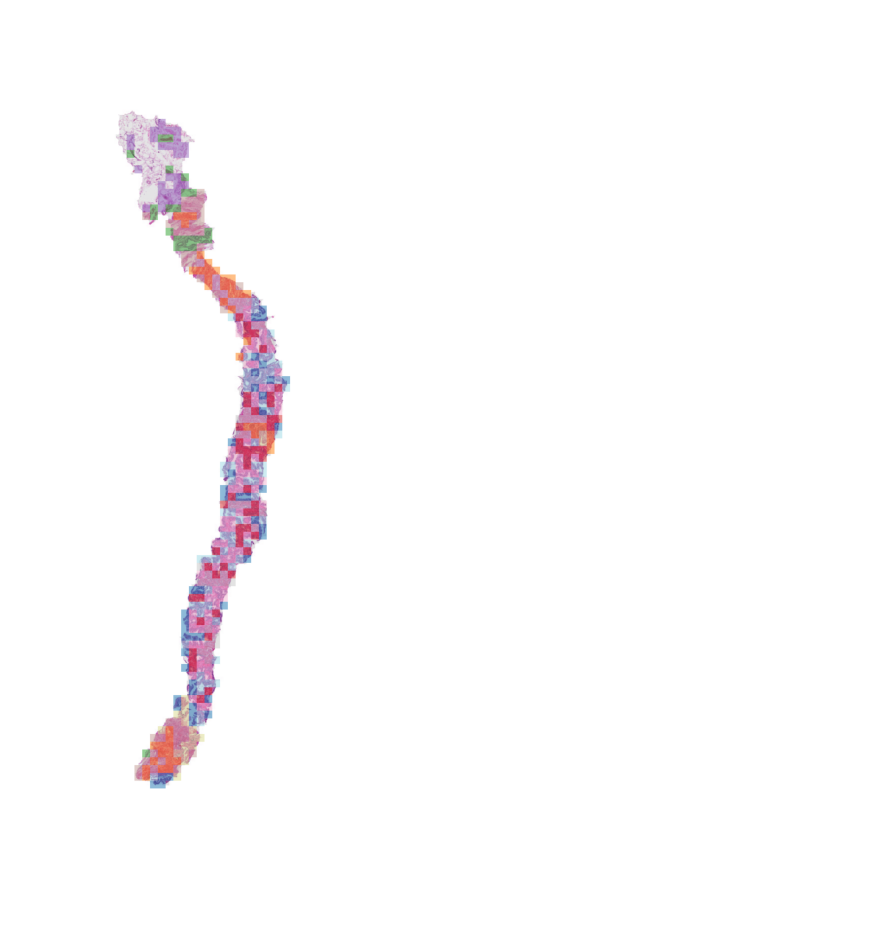

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [ ]:
analyzer.compute_feats_color(n_clusters=10)
analyzer.create_feature_viz(mode='clusters')
analyzer.visualise_overlay(alpha=0.5)

## Collect data

Here we see the printed values for slide

In [ ]:
slide_ids = operator.lookup_table([example_name], mode='slide')
collected = next(operator.slide_features_collector(collect_ids=slide_ids))

slide_collected_data = collected.copy()
print(collected.keys())

print("slide id:", collected.pop('id'), "\nshapes of each data:")
for k, v in collected.items():
    try:
        print(k, v.shape)
    except:
        print(k, v)

dict_keys(['coords', 'features', 'annotation', 'objects', 'coords_size', 'data_type', 'propagate_loss', 'id', 'label', 'text'])
slide id: 636e787f78194d8eb91f79f319d99821 
shapes of each data:
coords (1, 425, 2)
features (1, 425, 1536)
annotation (1, 425, 6)
objects [None]
coords_size 248
data_type single
propagate_loss True
label (1, 3)
text None


Serve the **slide** and we can create a **HW3 RGB image** as `overlay` *(downscaled based on thumbnail)*

slide id: 636e787f78194d8eb91f79f319d99821


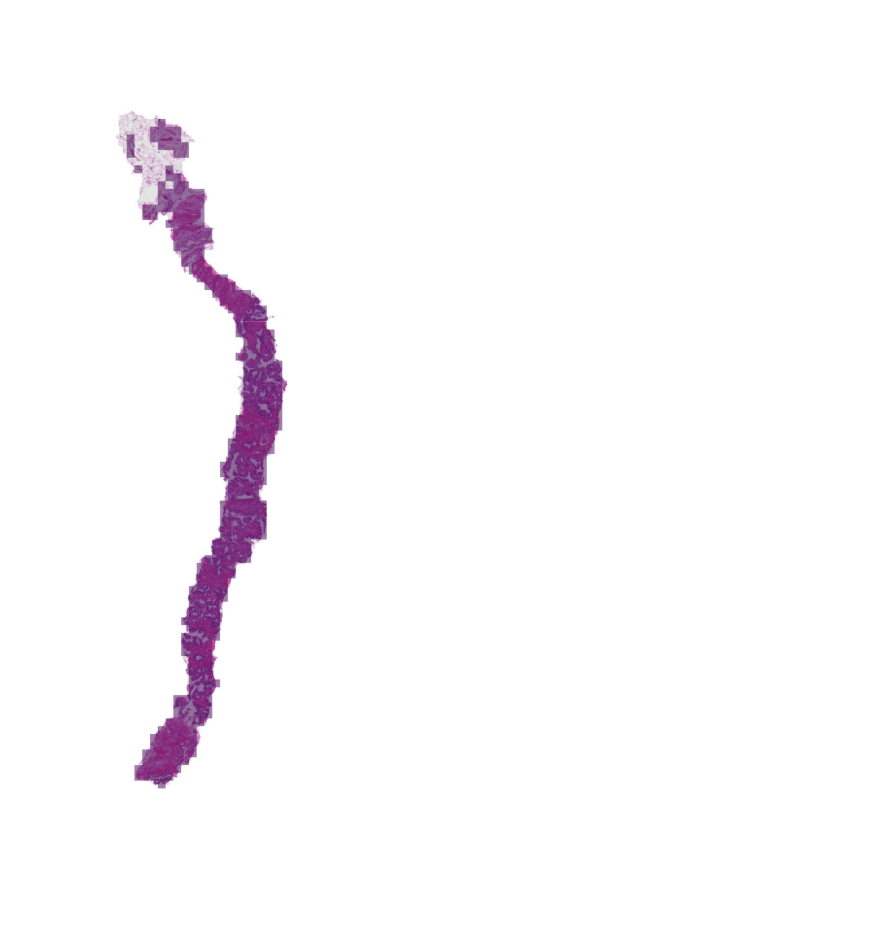

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [ ]:
analyzer = operator.serve_slide_analyzer(slide_collected_data['id'], data_modes='ann')
print("slide id:", slide_collected_data['id'])
viz = analyzer.create_annotation_viz(heatmap_target=None, mode='annotation')
viz.show()

Here we see the printed values for tile

In [ ]:
tile_ids = operator.lookup_table(["colon_ade_colonca95"], mode='tile')
collected = next(operator.tile_features_collector(collect_ids=tile_ids, cache=False))

tile_collected_data = collected.copy()
print(collected.keys())

print("tile id:", collected.pop('id'), "\nshapes of each data:")
for k, v in collected.items():
    try:
        print(k, v.shape)
    except:
        print(k, v)

StopIteration: 

## Downstream

Training & Evaluation

In [11]:
# operator.intitalise_inferencer(mode='tile')
# batch_size = 4
# operator.train(n_epochs=3, batch_size=batch_size)
# operator.evaluate(batch_size=batch_size)

In [12]:
operator.intitalise_inferencer(mode='slide')
batch_size = 16
operator.train(n_epochs=5, batch_size=batch_size)


SPLIT SUMMARY (By Slide ID)
Total Slides: 10615
Train: 8492 | Valid: 2123
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class0                  65.74              65.76
class1                  30.32              30.29
class2                   3.93               3.96

Result -> mnf_id: inf_6, epoch: 0


65it [00:25,  2.73it/s]

Resizing mask: Current scale 16.01x != Target 16x


2909it [21:26,  2.03it/s]

Resizing mask: Current scale 15.99x != Target 16x


...

Epoch 3/5 | train loss: -0.4663 | valid loss: -0.7281 | lr: 1.00e-04


8492it [49:09,  2.88it/s]
2123it [09:44,  3.63it/s]


Epoch 4/5 | train loss: -0.9534 | valid loss: -1.1928 | lr: 1.00e-04


8492it [35:03,  4.04it/s]
2123it [09:58,  3.54it/s]


Epoch 5/5 | train loss: -1.4051 | valid loss: -1.5850 | lr: 1.00e-04


In [13]:
operator.intitalise_inferencer(mode='slide', load_epoch=3)
eval_dict = operator.evaluate(batch_size=batch_size, eval_ids='valid')  # ['valid', 'train', 'all']


SPLIT SUMMARY (By Slide ID)
Total Slides: 10615
Train: 8492 | Valid: 2123
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class0                  65.74              65.76
class1                  30.32              30.29
class2                   3.93               3.96

Result -> mnf_id: inf_6, epoch: 3
Loaded epoch: 3


2123it [06:49,  5.19it/s]



--- Label Analysis (rank) ---


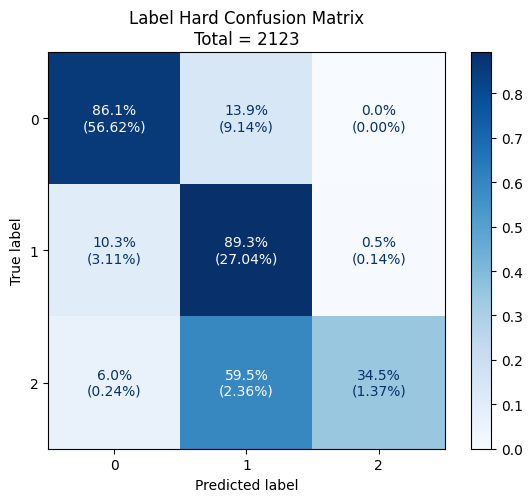

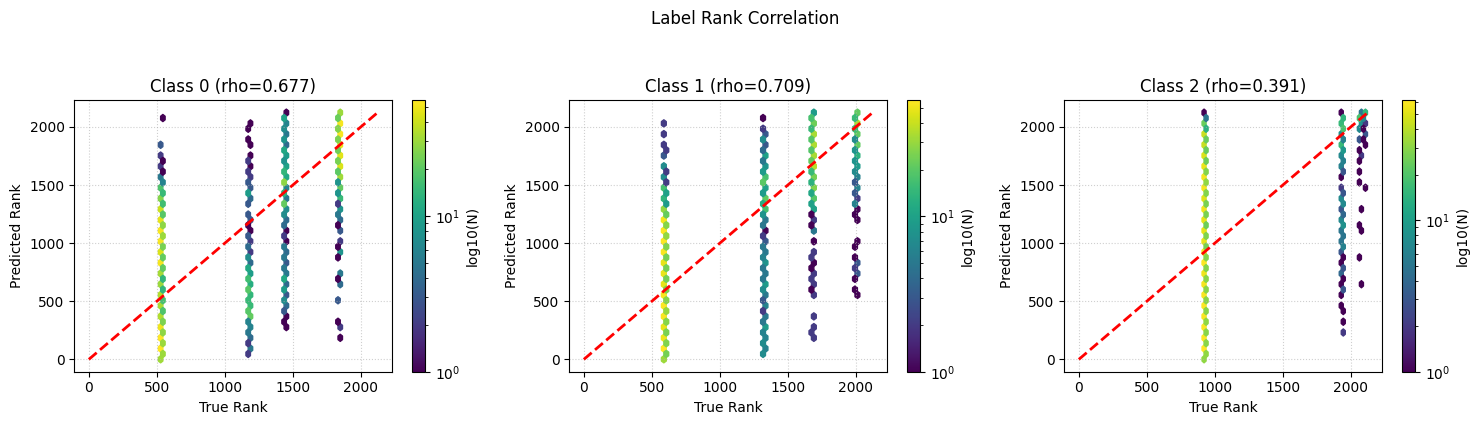

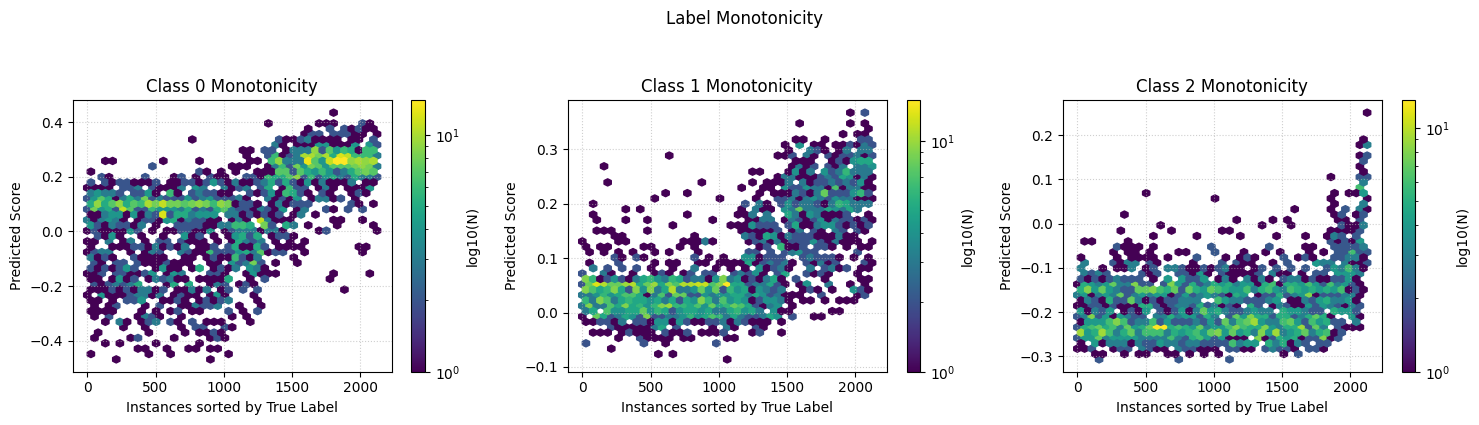


--- Annotation Analysis (rank) ---


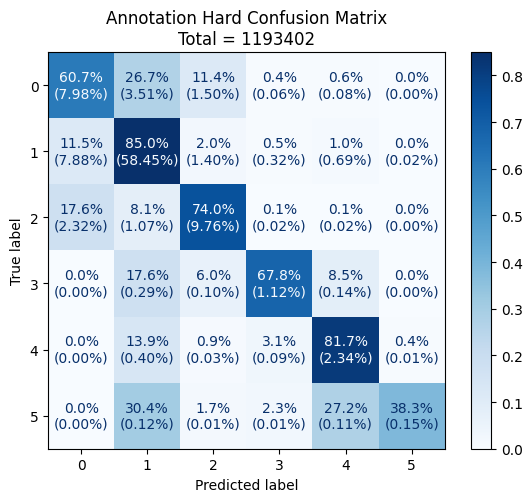

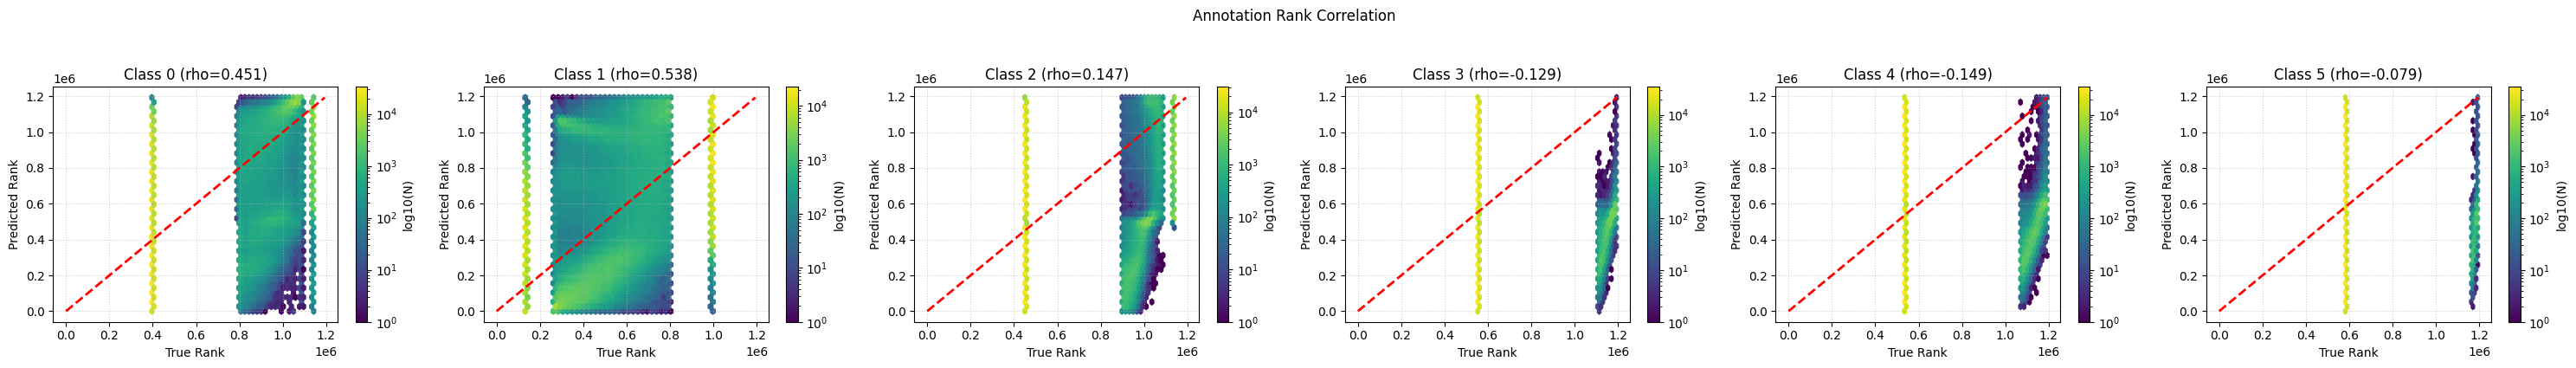

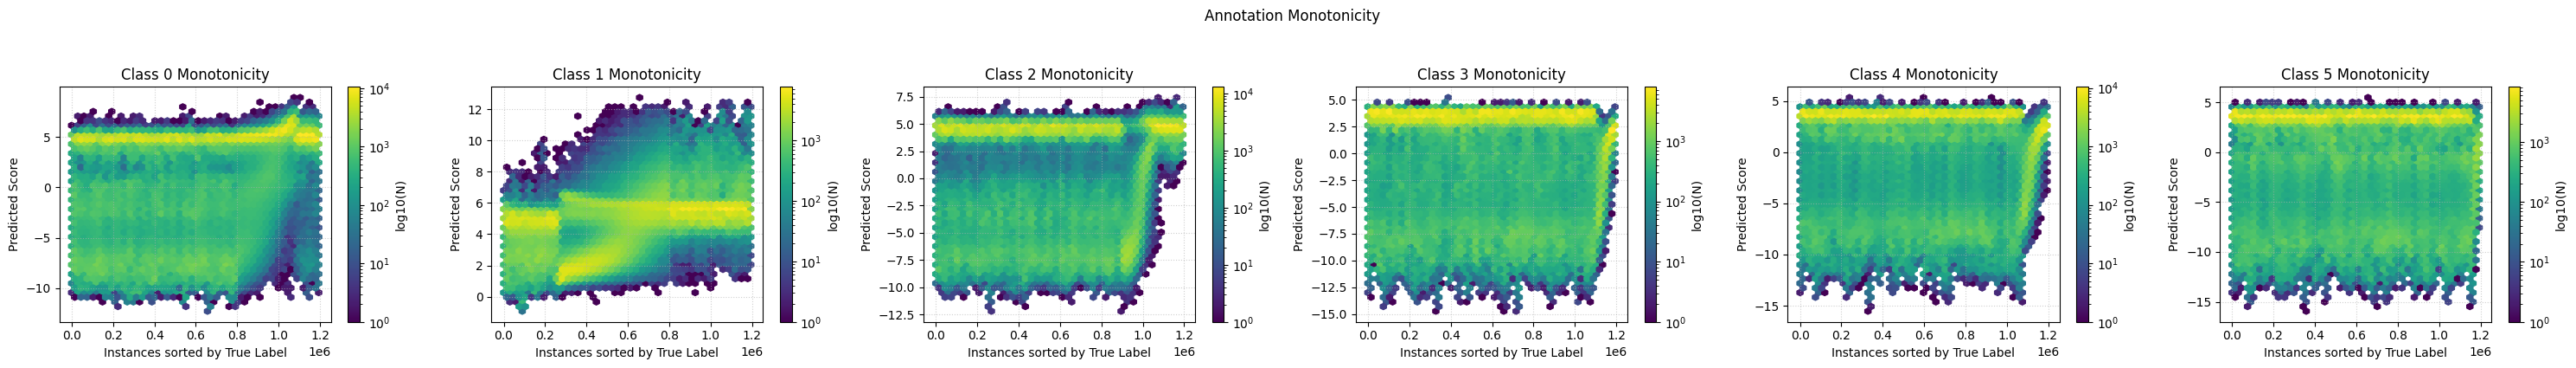

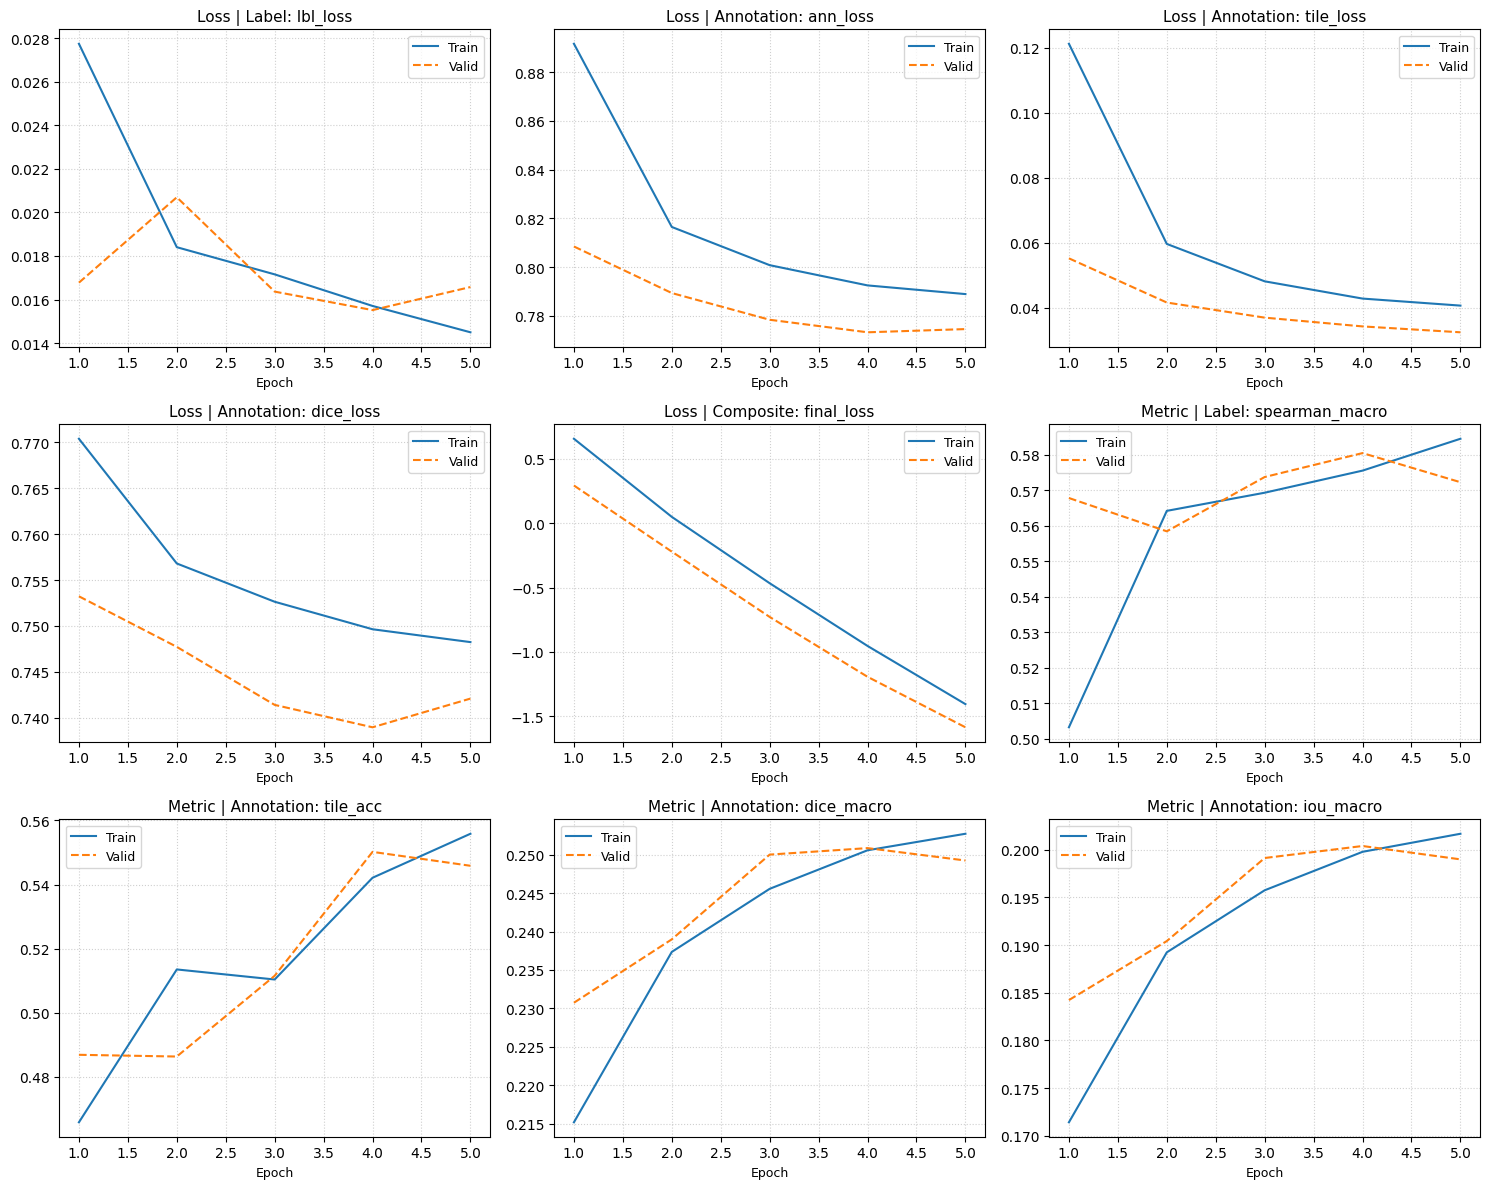

In [14]:
operator.val_graphs()
operator.plot_history()


SPLIT SUMMARY (By Slide ID)
Total Slides: 10615
Train: 8492 | Valid: 2123
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class0                  65.74              65.76
class1                  30.32              30.29
class2                   3.93               3.96

Result -> mnf_id: inf_6, epoch: 4
Loaded epoch: 4
prediction: [-0.20013772  0.11912238 -0.08220838]


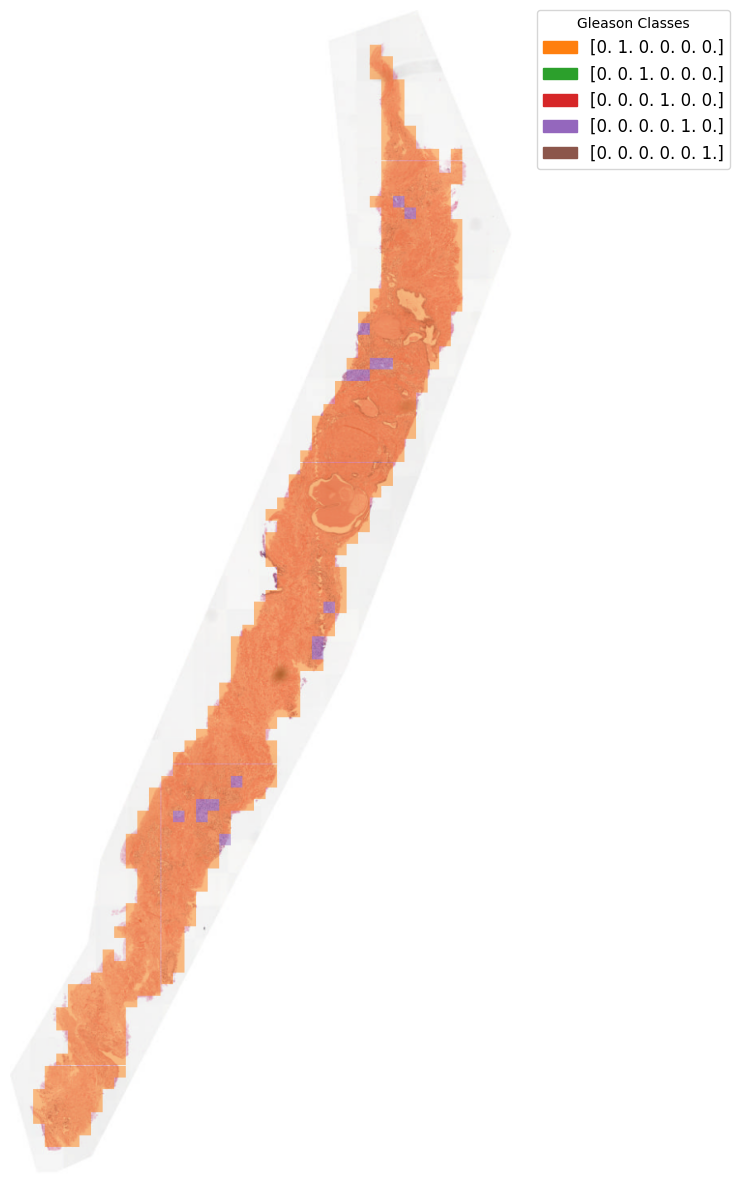

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [24]:
operator.intitalise_inferencer(mode='slide', load_epoch=4)

slide_id = operator.lookup_table(['00c52cb4db1c7a5811a8f070a910c038'], mode='slide')[0]
analyzer = operator.serve_slide_analyzer(slide_id, data_modes='pred')
print('prediction:', analyzer.mdata.pred.pred_lbl)
viz = analyzer.create_annotation_viz(heatmap_target=None, n_obj=None, mode='annotation')
viz.show()

## Searcher

In [ ]:
slide_id = operator.lookup_table("TCGA-2A-A8W3-01Z-00-DX1", mode='slide')[0]
operator.similarity_search(mode='slide', query_mode=['feat', 'roi'], query_feat_id=slide_id, query_roi_id=[0, 100, 1000])

Total samples: 195609
Training FAISS KMeans with K=16 on GPU=True...


SimDF(feat_res=                                 id  distance
0  0053594aace2405b9a7643f3a269b55c  0.000000
1  97f6a23681be4d4c9f0cc3079e3ab086  0.910029
2  7a99a1a050664d9e9258b8de9656a997  0.981227
3  de72952baf864194965b312825a875c9  1.070228
4  9d460dd26591453382129af59ad9887f  2.752589, roi_res=                                    cluster_id  composite_score  \
97f6a23681be4d4c9f0cc3079e3ab086 0           5         1.991777   
                                 1           2         1.870958   
                                 2           3         1.807743   
                                 3           0         1.664793   
                                 4           6         1.474637   
                                 5           4         1.457373   
                                 6           7         1.128541   
                                 7           8         0.972140   
                                 8           1         0.950569   
7a99a1a050664d9e9258b8de9656a9

In [ ]:
slide_ids = operator.lookup_table(["TCGA-2A-A8W3-01Z-00-DX1", "TCGA-2A-A8VV-01Z-00-DX1"], mode='slide')
operator.similarity_search(mode='slide', query_mode='img', query_feat_id=slide_ids, query_text=['hi', 'dude'])

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


SimDF(feat_res=None, roi_res=None, wrd_res=          wrd_0     wrd_1
img_0  0.023713  0.025081
img_1  0.063119  0.061831)

In [ ]:
tile_id = operator.lookup_table("colon_non-tumour_TCGA-3L-AA1B-01Z-00-DX1_10752_27136", mode='tile')[0]
operator.similarity_search(mode='tile', query_mode='feat', query_feat_id=tile_id, rebuild_index=True)


SPLIT SUMMARY (By Slide ID)
Total Slides: 31
Train: 24 | Valid: 7
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class1                  45.83              42.86
class2                  33.33              28.57
class4                  20.83              28.57

Result -> mnf_id: inf_1, epoch: 3
Loaded epoch: 3
Total samples: 31
Training FAISS KMeans with K=16 on GPU=True...


WARNING clustering 31 points to 16 centroids: please provide at least 624 training points


SimDF(feat_res=                                 id     distance
0  2184ff3eda5a439b9c00f5e5c74b915e     0.000000
1  ad1dff47171941999098c121e2dadaf3   373.692657
2  08a16f3a10144a4fb3bf77edb2f8f1f9   472.662628
3  728d3a3c1cdd4466b7ebbbbda26aebc0  1603.471313
4  03ba324130a74cb6bcf85f2eaf69cd39  1753.029297, roi_res=None, wrd_res=None)

In [ ]:
tile_ids = operator.lookup_table(["colon_ade_colonca98", "colon_ade_colonca93"], mode='tile')
operator.similarity_search(mode='tile', query_mode='img', query_feat_id=tile_ids, query_text=['hi', 'dude'])

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


SimDF(feat_res=None, roi_res=None, wrd_res=          wrd_0     wrd_1
img_0 -0.031799 -0.033255
img_1 -0.002020 -0.010632)